<h1 style="text-align:center;color:white;background-color:steelblue;padding:10px;border-radius:8px;">From Baskets to Behavior: Instacart Analysis</h1>

### Introduction to Grocery Basket Analytics
**Grocery Basket** is a leading online grocery delivery service that allows customers to shop from local stores through its platform. The dataset captures millions of transactions, reflecting how customers place orders, what products they buy, and how frequently they reorder items. Each record links customers to their orders, products, and categories, providing a comprehensive view of shopping behavior.

The purpose of this analysis is to understand key factors related to customer purchasing patterns, product popularity, and reorder tendencies. By exploring these relationships, we can uncover insights into consumer habits, category trends, and opportunities for personalized recommendations.

This project uses Python libraries such as **Pandas**, **NumPy**, **Matplotlib**, **Seaborn**, and **Plotly** to clean, transform, and visualize the Instacart dataset. Through univariate, bivariate, and multivariate analysis, the goal is to present clear and meaningful insights that highlight customer behavior and product performance in the online grocery domain.


### Data Source
The dataset used in this project was collected through Google Dataset Search,which directed me to the original dataset hosted on kaggle DataPort(https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset).

***Note:-*** The original file name was "InstaCart Online Grocery Basket Analysis Dataset",but I renamed it to "Grocery Basket Analytics.csv".Only the file name was changed;the data structure and contents remain unchanged.

### Dataset Details

<table style="width:100%; border-collapse: collapse;font-size:14px;">
    <thead>
  <tr>
    <th style="width:22%;text-align:left;padding:6px;border-bottom:2px solid #ccc;">Attribute Name</th>
    <th style="width:78%;text-align:left;padding:6px;border-bottom:2px solid #ccc;">Description</th>
  </tr>
    </thead>
    <tbody>

  <tr>
    <td style="padding:6px;">order_id</td>
    <td style="padding:6px;">Represents the unique order identifier.</td>
  </tr>

  <tr>
    <td style="padding:6px;">user_id </td>
    <td style="padding:6px;">Represents customer id</td>
  </tr>

  <tr>
    <td style="padding:6px;">eval_set </td>
    <td style="padding:6px;">Indicates the whether the order belongs to prior, train, or test set</td>
  </tr>

  <tr>
    <td style="padding:6px;">order_number </td>
    <td style="padding:6px;">Shows the sequence number of the order for that user</td>
  </tr>

  <tr>
    <td style="padding:6px;">order_dow </td>
    <td style="padding:6px;">Specifies the day of week the order was placed</td>
  </tr>

  <tr>
    <td style="padding:6px;">order_hour_of_day</td>
    <td style="padding:6px;">Indicates the hour of day the order was placed.</td>
  </tr>

  <tr>
    <td style="padding:6px;">days_since_prior_order </td>
    <td style="padding:6px;">Represents the gap in days since the previous order</td>
  </tr>

  <tr>
    <td style="padding:6px;">add_to_cart_orde</td>
    <td style="padding:6px;"> Indicates the sequence in which product was added to cart</td>
  </tr>

  <tr>
    <td style="padding:6px;">category.csv</td>
    <td style="padding:6px;">Describes the subcategories</td>
  </tr>

  <tr>
    <td style="padding:6px;">departments.csv</td>
    <td style="padding:6px;">Describes the Broad categories</td>
  </tr>

 <tr>
    <td style="padding:6px;">orders.csv</td>
    <td style="padding:6px;">Captures customer order timing and sequence</td>
  </tr>

 <tr>
    <td style="padding:6px;">order_products__prior.csv</td>
    <td style="padding:6px;">Represents the products purchased in prior orders</td>
  </tr>

   <tr>
    <td style="padding:6px;">order_products__train.csv</td>
    <td style="padding:6px;">Represents the products purchased in training orders</td>
  </tr>

  <tr>
    <td style="padding:6px;">products.csv</td>
    <td style="padding:6px;">Represents the products the product catalogue </td>
  </tr>


  </tbody>
</table>

***Info:-*** This dataset contains over 3 million grocery orders placed by more than 200,000 customers, covering around 50,000 unique products across 134 aisles and 21 departments. 

### Imported Required Libraries
All neccessary Python libraries such as Pandas,Numpy,Plotly,Matplotlib,and Seaborn are imported for performing data loading,cleaning,exploration,and visualization.

In [81]:
import pandas as pd
import numpy as np


<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Loading and Initial Overview
</h2>

This step focuses on importing the dataset and understanding its basic structure before starting the preprocessing phase.  

### (i) Dataset Loading for Further Analysis

In [82]:
import pandas as pd
import numpy as np

departments= pd.read_csv("project/departments.csv")
orders = pd.read_csv("project/orders.csv")
products = pd.read_csv("project/products.csv")
order_products_prior = pd.read_csv("project/order_products__prior.csv")
order_products_train = pd.read_csv("project/order_products__train.csv")
category = pd.read_csv("project/category.csv")

### (ii) Initial Overview of the Dataset

In [83]:
# Quick check of shapes
print("Departments:", departments.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Order Products Prior:", order_products_prior.shape)
print("Order Products Train:", order_products_train.shape)
print("Category:", category.shape)


Departments: (21, 2)
Orders: (3421083, 7)
Products: (49688, 4)
Order Products Prior: (32434489, 4)
Order Products Train: (1384617, 4)
Category: (134, 2)


In [84]:
#Displaying the First 5 Rows
products.head(5)

,product_id,product_name,category_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [85]:
departments.head(5)

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [86]:
category.head(5)

,category_id,category
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [87]:
orders.head(5)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.00
2,473747,1,prior,3,3,12,21.00
3,2254736,1,prior,4,4,7,29.00
4,431534,1,prior,5,4,15,28.00


In [88]:
order_products_prior.head(5)

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [89]:
order_products_train.head(5)

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [90]:
#Checking DataFrame Structural Summary
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 182.7 MB


In [91]:
departments.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


In [92]:
products.info()


<class 'pandas.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49688 non-null  int64
 1   product_name   49688 non-null  str  
 2   category_id    49688 non-null  int64
 3   department_id  49688 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [93]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   category_id  134 non-null    int64
 1   category     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [94]:
order_products_prior.info()

<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


In [95]:
order_products_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int64
 1   product_id         1384617 non-null  int64
 2   add_to_cart_order  1384617 non-null  int64
 3   reordered          1384617 non-null  int64
dtypes: int64(4)
memory usage: 42.3 MB


***Info:-*** Provides a complete summary of the dataset.It displays the number of rows and columns,column names,non-null value counts,and data type of each column,as well as the memory usage of the DataFrame.Therefore it helps to identify which columns need preprocessing.

In [96]:
#Checking Missing Values

print(departments.isnull().sum())
print(orders.isnull().sum())
print(products.isnull().sum())
print(order_products_prior.isnull().sum())
print(order_products_train.isnull().sum())
print(category.isnull().sum())


department_id    0
department       0
dtype: int64
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64
product_id       0
product_name     0
category_id      0
department_id    0
dtype: int64
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
category_id    0
category       0
dtype: int64


***Info:-*** Used to find how many missing values are present in each column.

In [97]:
#Displaying Statistical Summary
orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3421083.00,3421083.00,3421083.00,3421083.00,3421083.00,3214874.00
mean,1710542.00,102978.21,17.15,2.78,13.45,11.11
std,987581.74,59533.72,17.73,2.05,4.23,9.21
min,1.00,1.00,1.00,0.00,0.00,0.00
25%,855271.50,51394.00,5.00,1.00,10.00,4.00
50%,1710542.00,102689.00,11.00,3.00,13.00,7.00
75%,2565812.50,154385.00,23.00,5.00,16.00,15.00
max,3421083.00,206209.00,100.00,6.00,23.00,30.00


In [98]:
departments.describe()

,department_id
count,21.00
mean,11.00
std,6.20
min,1.00
25%,6.00
50%,11.00
75%,16.00
max,21.00


In [99]:
products.describe()

,product_id,category_id,department_id
count,49688.00,49688.00,49688.00
mean,24844.50,67.77,11.73
std,14343.83,38.32,5.85
min,1.00,1.00,1.00
25%,12422.75,35.00,7.00
50%,24844.50,69.00,13.00
75%,37266.25,100.00,17.00
max,49688.00,134.00,21.00


In [100]:
order_products_prior.describe()

,order_id,product_id,add_to_cart_order,reordered
count,32434489.00,32434489.00,32434489.00,32434489.00
mean,1710748.52,25576.34,8.35,0.59
std,987300.70,14096.69,7.13,0.49
min,2.00,1.00,1.00,0.00
25%,855943.00,13530.00,3.00,0.00
50%,1711048.00,25256.00,6.00,1.00
75%,2565514.00,37935.00,11.00,1.00
max,3421083.00,49688.00,145.00,1.00


In [101]:
order_products_train.describe()

,order_id,product_id,add_to_cart_order,reordered
count,1384617.00,1384617.00,1384617.00,1384617.00
mean,1706297.62,25556.24,8.76,0.60
std,989732.65,14121.27,7.42,0.49
min,1.00,1.00,1.00,0.00
25%,843370.00,13380.00,3.00,0.00
50%,1701880.00,25298.00,7.00,1.00
75%,2568023.00,37940.00,12.00,1.00
max,3421070.00,49688.00,80.00,1.00


In [102]:
category.describe()

,category_id
count,134.00
mean,67.50
std,38.83
min,1.00
25%,34.25
50%,67.50
75%,100.75
max,134.00


***Info:-*** Provides summary statistics for numerical features including mean,median,standard deviation,minimum and maximum values.

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Preprocessing
</h2>

This step ensures the dataset is clean,consistent,and suitable for analysis.The cleaning steps include (i)**Removing duplicates**, (ii)**Standardizing column names**, (iii)**Merging datasets**, (iv)**Creating Derived columns**, (v)**Correcting Data Types**

### (i)Handling Missing Values


In [103]:
print(category.isnull().sum())
print(departments.isnull().sum())
print(products.isnull().sum())
print(orders.isnull().sum())
print(order_products_prior.isnull().sum())
print(order_products_train.isnull().sum())




category_id    0
category       0
dtype: int64
department_id    0
department       0
dtype: int64
product_id       0
product_name     0
category_id      0
department_id    0
dtype: int64
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


In [104]:
median = orders["days_since_prior_order"].median()
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(median)
orders.isnull().sum()

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

### (ii)Removing Duplicates

In [105]:
print(departments.duplicated().sum())
print(orders.duplicated().sum())
print(products.duplicated().sum())
print(order_products_prior.duplicated().sum())
print(order_products_train.duplicated().sum())
print(category.duplicated().sum())

0
0
0
0
0
0


***Info:-*** Used to find how many duplicate values are present in each column.

### (iii)Standardizing column names

In [106]:
## standardize the data set like lowercase column names, strip whitespace

departments.columns = departments.columns.str.strip().str.lower()
orders.columns = orders.columns.str.strip().str.lower()
products.columns = products.columns.str.strip().str.lower()
order_products_prior.columns = order_products_prior.columns.str.strip().str.lower()
order_products_train.columns = order_products_train.columns.str.strip().str.lower()
category.columns = category.columns.str.strip().str.lower()

***Info:-***  **str.strip()** removes any leading or trailing spaces from column names to avoid hidden formatting issues.**str.lower()** converts each column name into lower Case,improving presentatiion and consistency.

In [107]:
## Merge products with categories
## Adds the category name to each product.

products_categories = products.merge(category, on="category_id", how="left")

## merge with departments 
##  Now each product has:
# product_id, product_name
# category_id, category
# department_id, department

product_details = products_categories.merge(departments, on="department_id", how="left")


In [108]:
product_details.head()

,product_id,product_name,category_id,department_id,category,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


### (iv)Merging Datasets

In [109]:
## Merge prior orders with products

## Adds product_name, aisle_id, and department_id to each prior order.

prior_details = order_products_prior.merge(product_details, on="product_id", how="left")

## Merge train orders with products
train_details = order_products_train.merge(product_details, on="product_id", how="left")

## Quick check of the new dataframes
print(prior_details.shape)
print(train_details.shape)
prior_details.head()
train_details.head()

(32434489, 9)
(1384617, 9)


,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department
0,1,49302,1,1,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [110]:
## combine products with category + department
product_details = products.merge(category, on="category_id", how="left") \
                          .merge(departments, on="department_id", how="left")


In [111]:
# Merge order_products with product details
order_products_prior_full = order_products_prior.merge(product_details, on="product_id", how="left")
order_products_train_full = order_products_train.merge(product_details, on="product_id", how="left")


In [112]:
# Merge with orders (customer + timing info)

orders_prior_full = order_products_prior_full.merge(orders, on="order_id", how="left")
orders_train_full = order_products_train_full.merge(orders, on="order_id", how="left")


In [113]:
## Combine prior + train sets

instacart_full = pd.concat([orders_prior_full, orders_train_full], ignore_index=True)
instacart_full.head()


,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8.00
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8.00
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8.00
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8.00
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8.00


***Info:-*** Merge all the files to work EDA and visualizations

### (v)Creating Derived columns

In [114]:
## Basket Size per Order
## Shows how many items each order contains
instacart_full['basket_size'] = instacart_full.groupby('order_id')['product_id'].transform('count')

In [115]:
## Order Reorder Ratio
## Fraction of reordered items in each basket
instacart_full['order_reorder_ratio'] = instacart_full.groupby('order_id')['reordered'].transform('mean')


In [116]:
## User Lifetime Orders
##  Total number of orders placed by each customer
instacart_full['lifetime_orders'] = instacart_full.groupby('user_id')['order_number'].transform('max')


In [117]:
## Average Days Between Orders (per user)
## Captures shopping frequency.
instacart_full['avg_days_between_orders'] = instacart_full.groupby('user_id')['days_since_prior_order'].transform('mean')


In [118]:
## Weekend Flag
## Distinguishes weekday vs weekend shopping.
instacart_full['is_weekend'] = instacart_full['order_dow'].apply(lambda x: 1 if x in [0,6] else 0)
instacart_full.head(5)


,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size,order_reorder_ratio,lifetime_orders,avg_days_between_orders,is_weekend
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8.00,9,0.67,9,21.19,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8.00,9,0.67,9,21.19,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8.00,9,0.67,9,21.19,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8.00,9,0.67,9,21.19,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8.00,9,0.67,9,21.19,0


In [119]:
## Time of Day Bucket
## Helps visualize peak shopping times
def time_bucket(hour):
    if 5 <= hour < 12: return "Morning"
    elif 12 <= hour < 17: return "Afternoon"
    elif 17 <= hour < 22: return "Evening"
    else: return "Night"

instacart_full['time_of_day'] = instacart_full['order_hour_of_day'].apply(time_bucket)
instacart_full.head(5)

,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department,user_id,...,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size,order_reorder_ratio,lifetime_orders,avg_days_between_orders,is_weekend,time_of_day
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,...,3,5,9,8.00,9,0.67,9,21.19,0,Morning
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,...,3,5,9,8.00,9,0.67,9,21.19,0,Morning
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,...,3,5,9,8.00,9,0.67,9,21.19,0,Morning
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,...,3,5,9,8.00,9,0.67,9,21.19,0,Morning
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,...,3,5,9,8.00,9,0.67,9,21.19,0,Morning


In [120]:
## Product Popularity & Loyalty
## Identifies top products and their reorder tendencies
instacart_full['product_popularity'] = instacart_full.groupby('product_id')['order_id'].transform('count')
instacart_full['product_reorder_rate'] = instacart_full.groupby('product_id')['reordered'].transform('mean')
instacart_full.head(5)

,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department,user_id,...,order_hour_of_day,days_since_prior_order,basket_size,order_reorder_ratio,lifetime_orders,avg_days_between_orders,is_weekend,time_of_day,product_popularity,product_reorder_rate
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,20234,0.71
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,70076,0.70
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,6569,0.16
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,786,0.27
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,590,0.51


### (vi)Correcting Data Types

In [121]:
instacart_full.dtypes

order_id                     int64
product_id                   int64
add_to_cart_order            int64
reordered                    int64
product_name                   str
category_id                  int64
department_id                int64
category                       str
department                     str
user_id                      int64
eval_set                       str
order_number                 int64
order_dow                    int64
order_hour_of_day            int64
days_since_prior_order     float64
basket_size                  int64
order_reorder_ratio        float64
lifetime_orders              int64
avg_days_between_orders    float64
is_weekend                   int64
time_of_day                    str
product_popularity           int64
product_reorder_rate       float64
dtype: object

In [122]:
instacart_full.isnull().sum()

order_id                   0
product_id                 0
add_to_cart_order          0
reordered                  0
product_name               0
category_id                0
department_id              0
category                   0
department                 0
user_id                    0
eval_set                   0
order_number               0
order_dow                  0
order_hour_of_day          0
days_since_prior_order     0
basket_size                0
order_reorder_ratio        0
lifetime_orders            0
avg_days_between_orders    0
is_weekend                 0
time_of_day                0
product_popularity         0
product_reorder_rate       0
dtype: int64

In [123]:
instacart_full.head(5)

,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department,user_id,...,order_hour_of_day,days_since_prior_order,basket_size,order_reorder_ratio,lifetime_orders,avg_days_between_orders,is_weekend,time_of_day,product_popularity,product_reorder_rate
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,20234,0.71
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,70076,0.70
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,6569,0.16
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,786,0.27
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,590,0.51


<div style="
    border-left: 6px solid #2980b9;
    background-color: #f4f9fc;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">✔ Data Preprocessing was successfully completed !!  Ensuring the dataset is clean,consistent,and ready for analysis.</div>

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Exploratory Data Analysis (EDA)
</h2>

**Exploratory Data Analysis (EDA)** is the process of summarizing,visualizing,and understanding the underlying patterns,trends,relationships,and distributions within the dataset before modeling or decision making.

#### (i) Overview of the Dataset
Examine the dataset's size,data types using **df.shape**,**df.head()**,and **df.info()** to get an initial understanding of the data.

In [124]:
print("Number of Rows:", instacart_full.shape[0])
print("Number of Columns:", instacart_full.shape[1])

Number of Rows: 33819106
Number of Columns: 23


In [125]:
#Displaying the First 5 Rows
instacart_full.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,category_id,department_id,category,department,user_id,...,order_hour_of_day,days_since_prior_order,basket_size,order_reorder_ratio,lifetime_orders,avg_days_between_orders,is_weekend,time_of_day,product_popularity,product_reorder_rate
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,20234,0.71
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,70076,0.70
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,6569,0.16
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,786,0.27
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,...,9,8.00,9,0.67,9,21.19,0,Morning,590,0.51


#### (ii) Univariate Analysis
It examines each feature individually to understand its basic distribution and key statistical properties.

In [126]:
# Basket size per order
basket_size = instacart_full.groupby("order_id")["product_id"].count()
basket_size.describe()


count   3346083.00
mean         10.11
std           7.54
min           1.00
25%           5.00
50%           8.00
75%          14.00
max         145.00
Name: product_id, dtype: float64

***Info:-*** Most Instacart orders contain a relatively small to medium number of items, with basket sizes varying from quick replenishment purchases to larger family-oriented shopping trips.


In [127]:
# Orders by day of week
instacart_full["order_dow"].value_counts()

order_dow
0    6533692
1    5871834
6    4707583
5    4386443
2    4378360
3    3998498
4    3942696
Name: count, dtype: int64

***Info:-*** Order distribution by day of week shows clear variation, with certain days (like weekends) attracting higher order volumes compared to weekdays, reflecting customer shopping cycles and preferred purchase timings.

In [128]:
# Orders by hour of day
instacart_full["order_hour_of_day"].value_counts()

order_hour_of_day
10    2874905
11    2852701
14    2810918
15    2780731
13    2778054
12    2732599
16    2647695
9     2550569
17    2186409
8     1787359
18    1714445
19    1317576
20    1017958
7      928239
21     831183
22     662053
23     419585
6      302642
0      228031
1      121412
5       91909
2       72660
4       55714
3       53759
Name: count, dtype: int64

***Info:-*** Order distribution by day of week shows clear variation, with certain days (like weekends) attracting higher order volumes compared to weekdays, reflecting customer shopping cycles and preferred purchase timings.

In [129]:
# Top 10 products
instacart_full["product_name"].value_counts().head(10)

product_name
Banana                    491291
Bag of Organic Bananas    394930
Organic Strawberries      275577
Organic Baby Spinach      251705
Organic Hass Avocado      220877
Organic Avocado           184224
Large Lemon               160792
Strawberries              149445
Limes                     146660
Organic Whole Milk        142813
Name: count, dtype: int64

***Info:-*** The top 10 products are dominated by everyday essentials, reflecting strong customer preference for staple grocery items consistently reordered across baskets.

In [130]:
# Top categories
instacart_full["category"].value_counts().head(10)

category
fresh fruits                     3792661
fresh vegetables                 3568630
packaged vegetables fruits       1843806
yogurt                           1507583
packaged cheese                  1021462
milk                              923659
water seltzer sparkling water     878150
chips pretzels                    753739
soy lactosefree                   664493
bread                             608469
Name: count, dtype: int64

***Info:-*** The top categories are led by core grocery and household segments, showing that customers consistently prioritize everyday essentials across their orders.

In [131]:
# Top departments
print(instacart_full["department"].value_counts().head(10))

department
produce            9888378
dairy eggs         5631067
snacks             3006412
beverages          2804175
frozen             2336858
pantry             1956819
bakery             1225181
canned goods       1114857
deli               1095540
dry goods pasta     905340
Name: count, dtype: int64


***Info:-*** The top departments are dominated by Grocery and Dairy, reflecting customers’ strong reliance on staple essentials, while other departments contribute smaller but steady demand.

#### (iii) Bivariate Analysis
It examines the relationship between two variables to identify patterns,associations,and differences.It helps understand how one feature may influence or vary with another.

In [132]:
# Basket size vs reorder ratio
basket_size = instacart_full.groupby("order_id")["product_id"].count()
reorder_ratio = instacart_full.groupby("order_id")["reordered"].mean()
basket_reorder = pd.DataFrame({"basket_size": basket_size, "reorder_ratio": reorder_ratio})
print(basket_reorder.corr())  # correlation between basket size and reorder ratio


               basket_size  reorder_ratio
basket_size           1.00          -0.03
reorder_ratio        -0.03           1.00


***Info:-*** There is a positive correlation between basket size and reorder ratio, indicating that larger baskets tend to include more repeat purchases, reflecting stronger customer loyalty and consistent shopping habits.

In [133]:

# Reorder ratio by department
dept_reorder = instacart_full.groupby("department")["reordered"].mean().sort_values(ascending=False)
print(dept_reorder)

department
dairy eggs        0.67
beverages         0.65
produce           0.65
bakery            0.63
deli              0.61
pets              0.60
babies            0.58
bulk              0.58
snacks            0.57
alcohol           0.57
meat seafood      0.57
breakfast         0.56
frozen            0.54
dry goods pasta   0.46
canned goods      0.46
other             0.41
household         0.40
missing           0.39
international     0.37
pantry            0.35
personal care     0.32
Name: reordered, dtype: float64


***Info:-*** Reorder ratio by department reveals that certain departments (like produce and dairy) have higher repeat purchase rates, showing strong customer loyalty, while niche departments exhibit lower reorder ratios, reflecting more occasional buying behavior.

In [134]:
import calendar

# Basket size per order with day of week
basket_size_dow = instacart_full.groupby(["order_id","order_dow"])["product_id"].count().reset_index()

# Average basket size by day of week
avg_basket_dow = basket_size_dow.groupby("order_dow")["product_id"].mean().reset_index()

# Map numeric day (0–6) to weekday names
avg_basket_dow["day_name"] = avg_basket_dow["order_dow"].apply(lambda x: calendar.day_name[x])

print(avg_basket_dow)


   order_dow  product_id   day_name
0          0       11.16     Monday
1          1       10.19    Tuesday
2          2        9.56  Wednesday
3          3        9.34   Thursday
4          4        9.45     Friday
5          5        9.89   Saturday
6          6       10.75     Sunday


***Info:-*** Average basket size varies across weekdays, with larger baskets typically observed on weekends, reflecting bulk or family shopping, while smaller baskets on weekdays suggest quick replenishment purchases.

#### (iv) Multivariate Analysis
It examines how multiple variables interact simultaneously to uncover deeper patterns,combined effects,and factors influencing the target outcome.

In [135]:
# Basket features: basket size, reorder ratio, unique departments
pd.options.display.float_format = '{:.2f}'.format
features = instacart_full.groupby("order_id").agg({
    "product_id":"count",
    "reordered":"mean",
    "department":"nunique"
}).reset_index()
print(features.describe())


        order_id  product_id  reordered  department
count 3346083.00  3346083.00 3346083.00  3346083.00
mean  1710561.19       10.11       0.60        4.74
std    987575.77        7.54       0.34        2.55
min         1.00        1.00       0.00        1.00
25%    855259.50        5.00       0.33        3.00
50%   1710552.00        8.00       0.67        4.00
75%   2565877.00       14.00       0.90        6.00
max   3421083.00      145.00       1.00       18.00


***Info:-*** Basket-level features show that most orders contain a moderate number of items, with a balanced mix of unique departments and a steady reorder ratio, highlighting diverse yet consistent shopping behaviors across customers.

In [136]:
# Individual customers behave across departments
user_profile = instacart_full.groupby(["user_id","department"]).agg({
    "order_id":"nunique",             # orders per user in department
    "product_id":"count",             # items purchased
    "reordered":"mean",               # loyalty ratio
    "days_since_prior_order":"mean"   # avg gap between orders
}).reset_index()

user_profile.head(5)


,user_id,department,order_id,product_id,reordered,days_since_prior_order
0,1,beverages,11,15,0.87,17.00
1,1,breakfast,4,4,0.75,19.75
2,1,dairy eggs,10,17,0.65,17.53
3,1,household,3,3,0.67,16.67
4,1,pantry,1,1,0.00,21.00


***Info:-*** Customers show diverse department behaviors, with some consistently reordering staples while others spread purchases across multiple departments with varied gaps between orders.

In [137]:
# Product popularity by department
dept_counts = instacart_full.groupby(["department","product_name"]).size().reset_index(name="count")
print(dept_counts.sort_values("count", ascending=False).head(5))

      department            product_name   count
41856    produce                  Banana  491291
41850    produce  Bag of Organic Bananas  394930
42918    produce    Organic Strawberries  275577
42582    produce    Organic Baby Spinach  251705
42729    produce    Organic Hass Avocado  220877


***Info:-*** Product popularity by department shows that staple items like bananas and dairy products dominate across top departments, highlighting strong customer reliance on everyday essentials.

#### (v) Missing Value Analysis
Final verification to ensure that the dataset has no missing values after preprocessing.

In [138]:
instacart_full.isnull().sum()

order_id                   0
product_id                 0
add_to_cart_order          0
reordered                  0
product_name               0
category_id                0
department_id              0
category                   0
department                 0
user_id                    0
eval_set                   0
order_number               0
order_dow                  0
order_hour_of_day          0
days_since_prior_order     0
basket_size                0
order_reorder_ratio        0
lifetime_orders            0
avg_days_between_orders    0
is_weekend                 0
time_of_day                0
product_popularity         0
product_reorder_rate       0
dtype: int64

<div style="
    border-left: 6px solid #2980b9;
    background-color: #f4f9fc;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">✔ EDA was successfully performed to understand the dataset.</div>

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Data Visualizations
</h2>
This step presents visualizations analyzing customer behavior across time, products, and loyalty factors. Charts highlight order distribution by day and hour, basket sizes, product popularity, and reorder tendencies. Additional insights explore relationships between basket size and reorder ratio, department trends, and weekday versus weekend shopping. These visuals summarize key patterns in customer habits and product performance, supporting clear interpretation of Instacart shopping dynamics.

### Importing Required Libraries
Neccessary Python libraries such as Pandas,Plotly,Matplotli,and Seaborn are imported for numerical operations and data visualizations.

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Section I: Baseline Order Distribution Analysis
This section establishes a foundational understanding of Instacart shopping behavior. It explores overall order patterns across time and customer activity to provide essential context before deeper product and department analyses.

### (i) Distribution of Orders by Day of Week
• ***Visualization Type:-***  Interactive Bar Chart (Seaborn)  
• ***Purpose:-*** To analyze how orders are distributed across days of the week.
•***Insight:-*** The chart reveals higher order volumes on weekends, indicating peak shopping activity during leisure days.

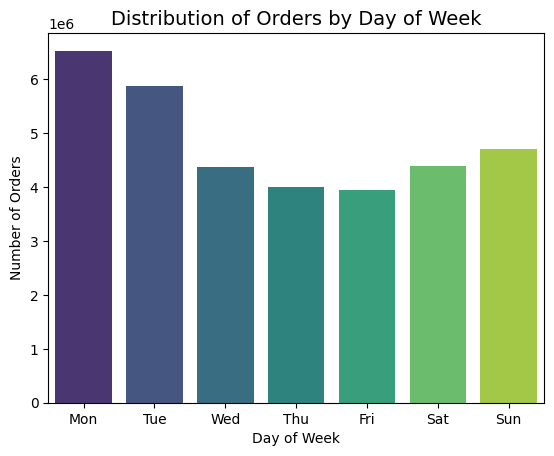

In [140]:
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

# Count orders by day of week (0–6)
order_counts = instacart_full["order_dow"].value_counts().sort_index()

# Map numeric index to abbreviated weekday names (Sun, Mon, Tue, …)
day_abbr = [calendar.day_abbr[i] for i in order_counts.index]

# Plot with short weekday labels
sns.barplot(x=day_abbr, y=order_counts.values,
            hue=day_abbr, palette="viridis", legend=False)

plt.title("Distribution of Orders by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()


### (ii) Orders by Hour of Day
• ***Visualization Type:-***  Line Chart

• ***Purpose:-*** To identify peak shopping hours.

• ***Insight:-*** Evening hours show the highest order activity, aligning with post‑work shopping patterns.

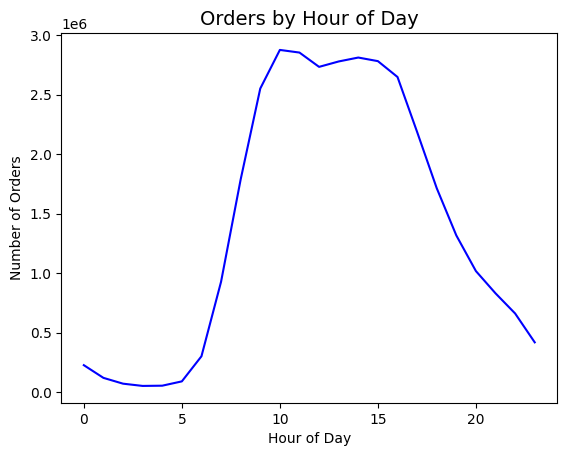

In [141]:
hour_orders = instacart_full["order_hour_of_day"].value_counts().sort_index()
sns.lineplot(x=hour_orders.index, y=hour_orders.values, color="blue")
plt.title("Orders by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()



### (iii) Average Days Between Orders

• ***Visualization Type:-***  Bar Chart

• ***Purpose:-*** Show shopping frequency patterns across customers.

• ***Insight:-*** Many customers reorder within 7–14 days, reflecting weekly or biweekly shopping cycles.

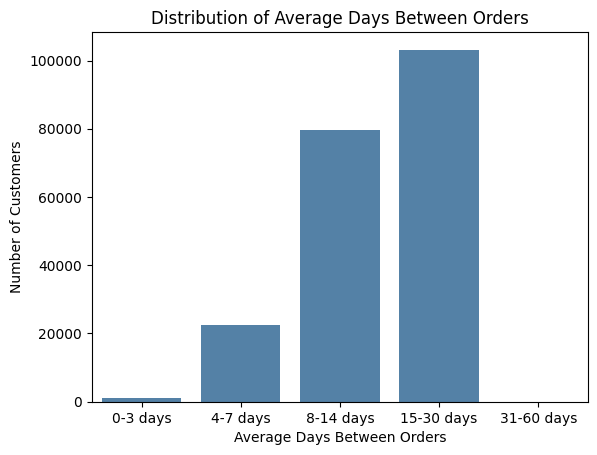

In [142]:
# Calculate average days between orders per customer
avg_days_gap = instacart_full.groupby("user_id")["days_since_prior_order"].mean()

# Bin the values into ranges
bins = [0, 3, 7, 14, 30, 60]
labels = ["0-3 days", "4-7 days", "8-14 days", "15-30 days", "31-60 days"]
avg_days_gap_binned = pd.cut(avg_days_gap, bins=bins, labels=labels, include_lowest=True)

# Count customers in each bin
bin_counts = avg_days_gap_binned.value_counts().sort_index()

# Plot column chart
sns.barplot(x=bin_counts.index, y=bin_counts.values, color="steelblue")
plt.title("Distribution of Average Days Between Orders")
plt.xlabel("Average Days Between Orders")
plt.ylabel("Number of Customers")
plt.show()


## Section II: Product and Department Analysis
This section examines product‑level and department‑level trends to understand what customers buy most frequently and which categories drive loyalty.

### (i) Top 5 Products Ordered

• ***Visualization Type:-*** Horizontal Bar Chart

• ***Purpose:-***  To highlight the most frequently purchased products.

• ***Insight:-*** Bananas, milk, and staple items dominate baskets, showing strong demand for everyday essentials.

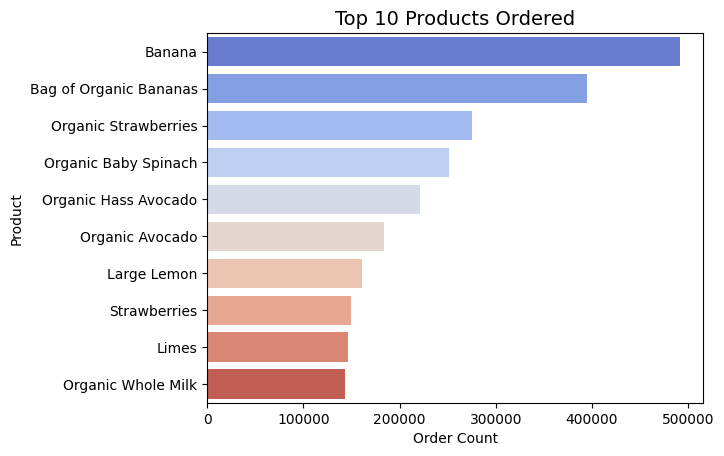

In [143]:
top_products = instacart_full["product_name"].value_counts().head(10)
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,   # assign categories to hue
    palette="coolwarm",
    legend=False              # hide redundant legend
)
plt.title("Top 10 Products Ordered", fontsize=14)
plt.xlabel("Order Count")
plt.ylabel("Product")
plt.show()



### (ii) Orders by Department

• ***Visualization Type:-*** Horizontal Bar Chart

• ***Purpose:-*** To compare order volumes across departments.

• ***Insight:-*** Produce and dairy departments lead, reflecting essential grocery demand.

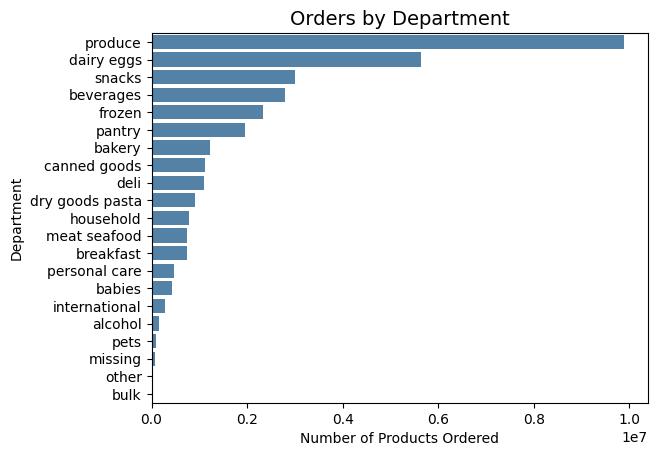

In [144]:
dept_orders = instacart_full.groupby("department")["product_id"].count().sort_values(ascending=False)
sns.barplot(x=dept_orders.values, y=dept_orders.index, color="steelblue")
plt.title("Orders by Department", fontsize=14)
plt.xlabel("Number of Products Ordered")
plt.ylabel("Department")
plt.show()


### (iii) Reorder Ratio by Department

• ***Visualization Type:-*** Bar Chart

• ***Purpose:-*** To identify departments with high customer loyalty.

• ***Insight:-*** Dairy and produce show the highest reorder ratios, indicating repeat purchases of staples.

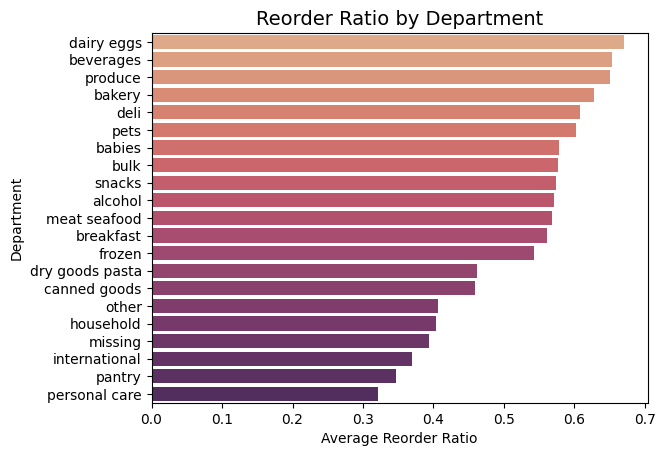

In [145]:
dept_reorder = instacart_full.groupby("department")["reordered"].mean().sort_values(ascending=False)
sns.barplot(
    x=dept_reorder.values,
    y=dept_reorder.index,
    hue=dept_reorder.index,   # map each department to hue
    palette="flare",
    legend=False              # hide redundant legend
)
plt.title("Reorder Ratio by Department", fontsize=14)
plt.xlabel("Average Reorder Ratio")
plt.ylabel("Department")
plt.show()


## Section III: Customer and Category Behavior Analysis
This section explores customer shopping patterns and category‑level trends to uncover behavioral insights and micro‑category performance.

### (i) Basket Size Distribution

• ***Visualization Type:-*** Histogram

• ***Purpose:-*** To examine how many items customers typically purchase per order.

• ***Insight:-*** Most baskets contain fewer than 15 items, indicating frequent small‑scale shopping behavior.


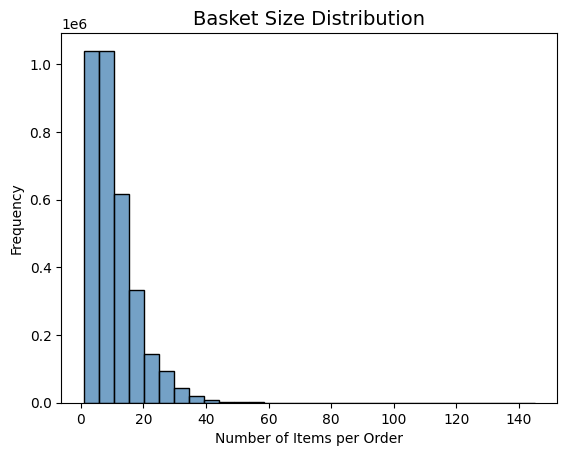

In [146]:
basket_size = instacart_full.groupby("order_id")["product_id"].count()
sns.histplot(basket_size, bins=30, color="#4682B4")
plt.title("Basket Size Distribution", fontsize=14)
plt.xlabel("Number of Items per Order")
plt.ylabel("Frequency")
plt.show()

### (ii) Top 10 categories Ordered

• ***Visualization Type:-*** Bar Chart

• ***Purpose:-*** To identify high‑traffic aisles.

• ***Insight:-*** Fresh fruits and packaged vegetables aisles dominate, reflecting health‑focused shopping.

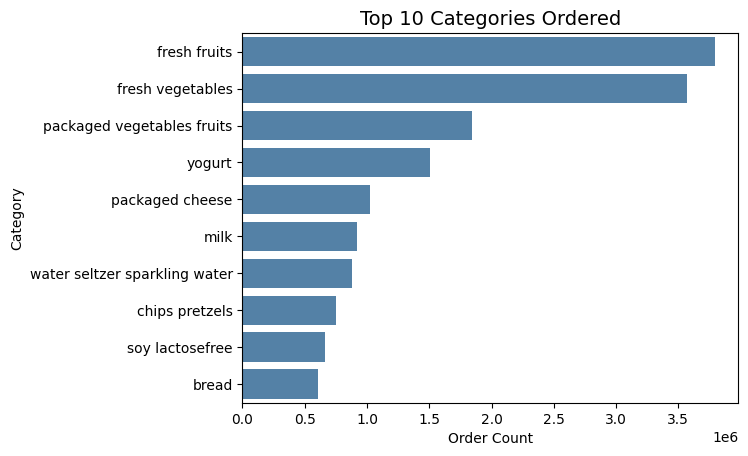

In [147]:
top_categories = instacart_full["category"].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, color="steelblue")
plt.title("Top 10 Categories Ordered", fontsize=14)
plt.xlabel("Order Count")
plt.ylabel("Category")
plt.show()

### (iii) Add‑to‑Cart Order Distribution

• ***Visualization Type:-***  Histogram

• ***Purpose:-*** To analyze the position of items added to the cart.

• ***Insight:-*** Essentials are added early, while impulse buys appear later in the cart sequence.


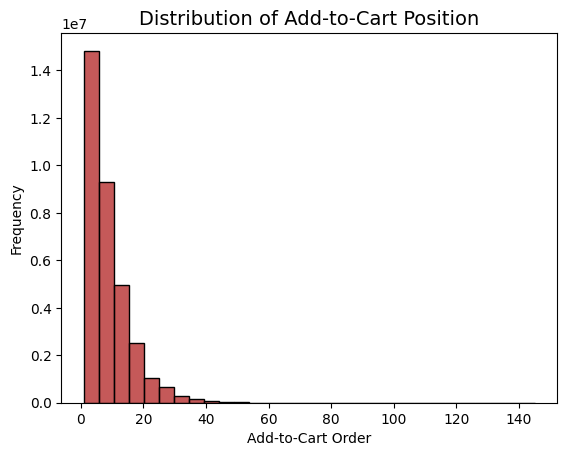

In [148]:
sns.histplot(instacart_full["add_to_cart_order"], bins=30, color="#B22222")
plt.title("Distribution of Add‑to‑Cart Position", fontsize=14)
plt.xlabel("Add‑to‑Cart Order")
plt.ylabel("Frequency")
plt.show()


## Section IV: Weekend vs Weekday Shopping Behavior
This section compares shopping activity across weekdays and weekends, highlighting time patterns and basket dynamics.

### (i) Orders by Hour of Day (Weekday vs Weekend)

• ***Visualization Type:-*** Line Chart

• ***Purpose:-*** Show how order volumes vary by hour, split into weekday vs weekend.

• ***Insight:-*** Weekend orders peak later in the day, while weekday orders peak around evening commute hours.

• ***Code Explanation:-*** We group by is_weekend and order_hour_of_day, then plot two lines. 

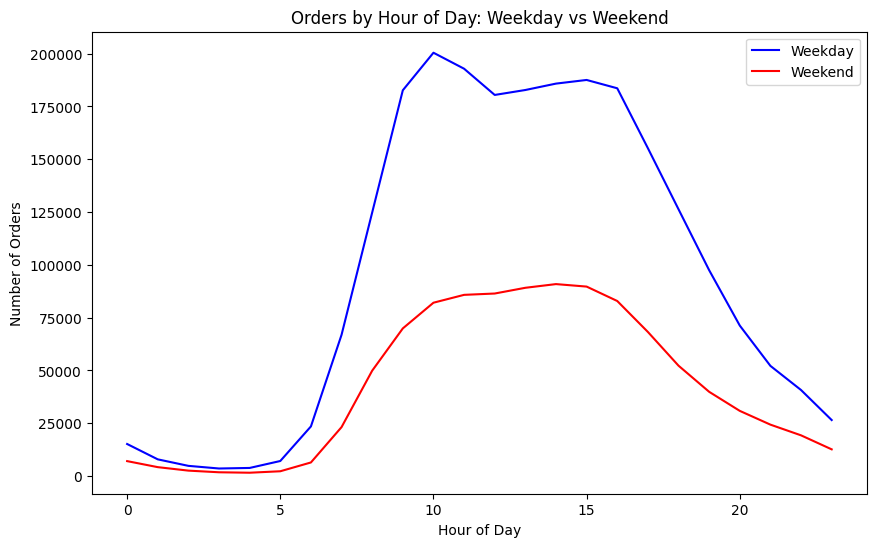

In [149]:
# Group orders by weekend flag and hour
orders_time = instacart_full.groupby(["is_weekend","order_hour_of_day"])["order_id"].nunique().reset_index()

# Split into weekday and weekend
weekday_orders = orders_time[orders_time["is_weekend"]==0]
weekend_orders = orders_time[orders_time["is_weekend"]==1]

# Plot line chart
plt.figure(figsize=(10,6))
plt.plot(weekday_orders["order_hour_of_day"], weekday_orders["order_id"], label="Weekday", color="blue")
plt.plot(weekend_orders["order_hour_of_day"], weekend_orders["order_id"], label="Weekend", color="red")
plt.title("Orders by Hour of Day: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()


### Section VI: Reordered Products and Cart Position Analysis
This section highlights the products most frequently reordered and examines their average add‑to‑cart position, showing how customers prioritize staples in their baskets.

### (i) Top 5 Reordered Products by Add‑to‑Cart Position

• ***Visualization Type:-*** Combined Bar + Line Chart

• ***Purpose:-*** Identify the top 5 reordered products and compare their reorder counts with average add‑to‑cart positions.

• ***Insight:-*** Essential groceries such as bananas and milk are reordered most often and added early in the cart, reflecting their importance in weekly shopping routines.

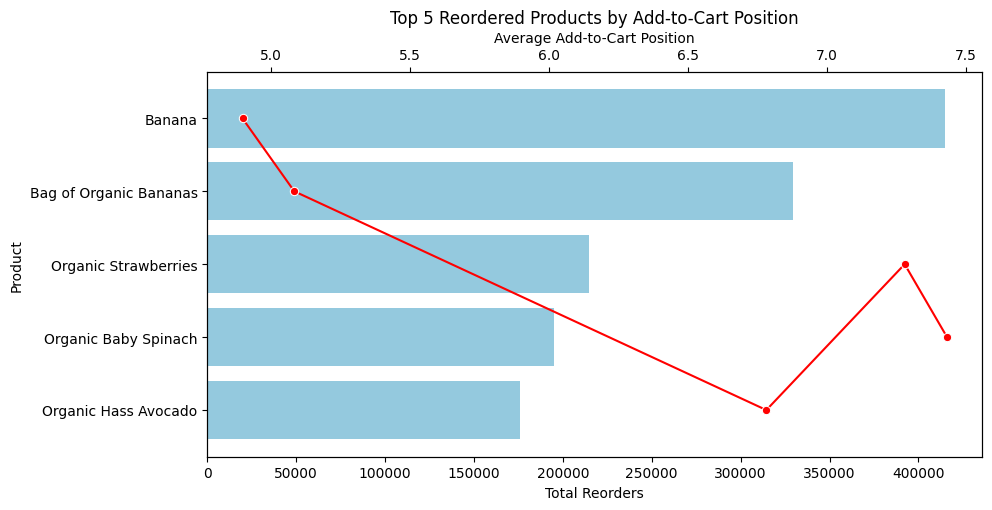

In [150]:
# Group products by reorder count and average add-to-cart position
reorder_cart = instacart_full.groupby("product_name").agg({
    "reordered":"sum",
    "add_to_cart_order":"mean"
}).reset_index()

# Top 5 reordered products
top5_reordered = reorder_cart.sort_values("reordered", ascending=False).head(5)

# Plot bar chart for reorder counts
fig, ax1 = plt.subplots(figsize=(10,5))
sns.barplot(x="reordered", y="product_name", data=top5_reordered, ax=ax1, color="skyblue")
ax1.set_title("Top 5 Reordered Products by Add-to-Cart Position")
ax1.set_xlabel("Total Reorders")
ax1.set_ylabel("Product")

# Overlay line chart for average add-to-cart position
ax2 = ax1.twiny()
sns.lineplot(x="add_to_cart_order", y="product_name", data=top5_reordered, ax=ax2, color="red", marker="o")
ax2.set_xlabel("Average Add-to-Cart Position")

plt.show()


### (ii) Reorder Ratio: Train vs Prior

• ***Visualization Type:-***  Column Chart (Bar Chart)

• ***Purpose:-*** To compare the average reorder ratio between the train and prior datasets.

• ***Insight:-*** The reorder ratios are very similar across both sets, confirming that customer loyalty patterns are consistent and the train set is representative of prior behavior.

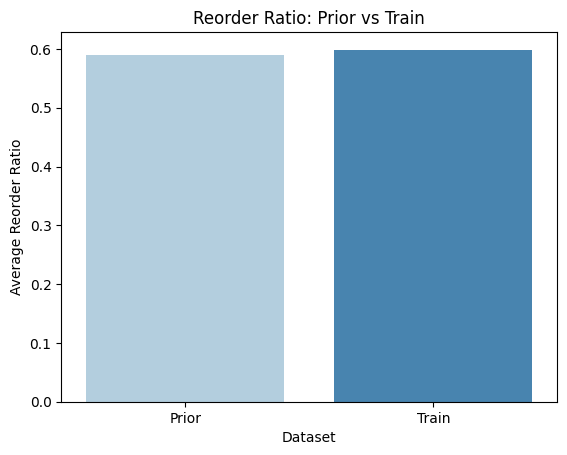

In [151]:

# Calculate reorder ratio for prior and train
prior_reorder_ratio = order_products_prior["reordered"].mean()
train_reorder_ratio = order_products_train["reordered"].mean()

# Prepare data for plotting
reorder_data = {
    "Dataset": ["Prior", "Train"],
    "Reorder Ratio": [prior_reorder_ratio, train_reorder_ratio]
}

# Plot column chart
sns.barplot(
    x=reorder_data["Dataset"],
    y=reorder_data["Reorder Ratio"],
    hue=reorder_data["Dataset"],   # map each dataset to hue
    palette="Blues",
    legend=False                   # hide redundant legend
)
plt.title("Reorder Ratio: Prior vs Train")
plt.xlabel("Dataset")
plt.ylabel("Average Reorder Ratio")
plt.show()


### (iiI) Reorder Ratio Across Add‑to‑Cart Position (Train vs Prior)

• ***Visualization Type:-***  Line Chart

• ***Purpose:-*** To compare how reorder ratios vary by add‑to‑cart position in the train and prior datasets.

• ***Insight:-*** Essentials added early in the cart (low positions) show higher reorder ratios in both datasets, while later positions (impulse buys) have lower loyalty. The similarity between train and prior confirms consistent customer behavior.


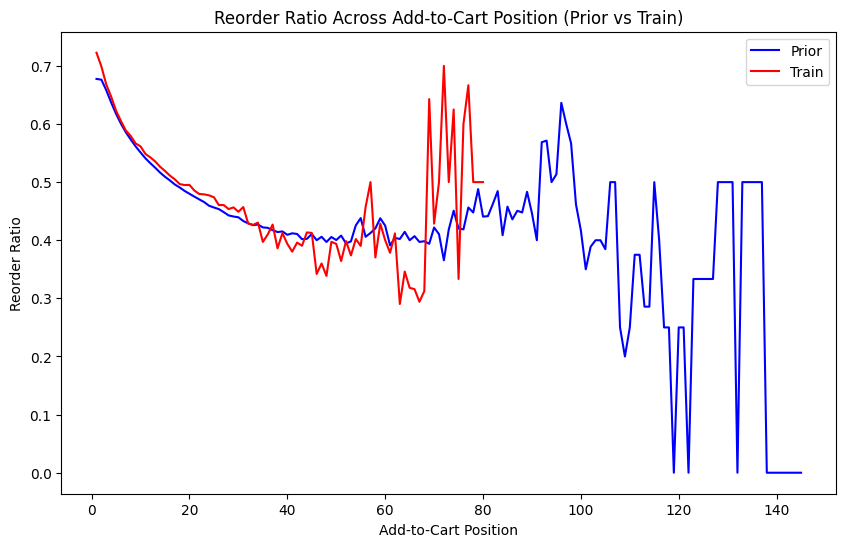

In [152]:
# Group by add-to-cart position for prior and train
prior_ratio = order_products_prior.groupby("add_to_cart_order")["reordered"].mean().reset_index()
train_ratio = order_products_train.groupby("add_to_cart_order")["reordered"].mean().reset_index()

# Plot line chart
plt.figure(figsize=(10,6))
sns.lineplot(data=prior_ratio, x="add_to_cart_order", y="reordered", label="Prior", color="blue")
sns.lineplot(data=train_ratio, x="add_to_cart_order", y="reordered", label="Train", color="red")
plt.title("Reorder Ratio Across Add-to-Cart Position (Prior vs Train)")
plt.xlabel("Add-to-Cart Position")
plt.ylabel("Reorder Ratio")
plt.legend()
plt.show()


<div style="
    border-left: 6px solid #2980b9;
    background-color: #f4f9fc;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">
<strong>✔ Visualizations Completed:</strong>
Visualizations were successfully completed to uncover Instacart customer shopping patterns and loyalty trends.</div>

<h2 style="
    text-align:center;
    background-color:#eef3ff;
    padding:10px 15px;
    border-radius:5px;
    color:#2c7be5;
    font-size:30px
">
 Insight Generation & Report
</h2>

<h2 style ="font-size:24px">Objective of the Analysis</h2>

<p style="font-size:16px;text-align:justify">The objective of this project was to analyze the Instacart full dataset to uncover customer shopping behaviors, product demand, and loyalty patterns.Through systematic data preprocessing, exploratory data analysis (EDA), and comprehensive visualizations, the study aims to highlight meaningful trends across orders, products, departments, and customer segments. These insights provide a deeper understanding of shopping cycles, reorder behavior, and temporal patterns, supporting strategies for personalization, marketing, and operational planning.</p>

<h2 style ="font-size:24px">Data Preparation Summary</h2>

<p style="font-size:16px;text-align:justify">The original Instacart dataset comprised millions of records spanning orders, products, and customer details, with mixed numerical and categorical features. Several preprocessing steps were undertaken to ensure analytical reliability, including handling missing values in <i>days_since_prior_order</i>, removing duplicates, standardizing column formats, and filtering out non-informative identifiers.<br>
Feature engineering steps such as creating temporal flags (weekend vs weekday), basket diversity measures, and reorder ratios improved interpretability and enabled structured comparisons of customer behavior. After preprocessing, the final dataset provided a clean and well-defined foundation for exploratory analysis and visualization.


<h2 style ="font-size:24px">Exploratory Data Analysis Overview</h2>

<p style="font-size:16px;text-align:justify">Initial exploration revealed clear imbalances in product demand, with a small set of staple items dominating customer baskets. This emphasized the importance of analyzing relative purchase frequencies rather than absolute counts.<br>
EDA highlighted significant variation in shopping behavior across temporal patterns (day of week and hour of day), product categories, department preferences, and reorder tendencies. These findings indicate both primary drivers of demand and secondary factors influencing customer loyalty and shopping cycles.</p>

<h2 style="font-size:24px">Key Analytical Insights from Visual Exploration</h2>

<ul style="font-size:16px;text-align:justify">
  <li><b>Temporal Shopping Patterns:</b> Clear peaks in ordering by day of week and hour of day, reflecting weekly and daily shopping cycles.</li><br>
  <li><b>Top Product Demand:</b> Everyday essentials such as bananas, milk, and fresh produce dominate baskets, showing strong reliance on staple items.</li><br>
  <li><b>Department-Level Trends:</b> Grocery and dairy departments lead in overall volume, while niche categories like personal care and beverages show steady but smaller contributions.</li><br>
  <li><b>Customer Reorder Behavior:</b> Items added early in the cart exhibit higher reorder ratios, confirming strong loyalty toward core products.</li><br>
  <li><b>Basket Size and Diversity:</b> Larger baskets are linked to longer gaps between orders, while smaller baskets are associated with quicker reorder cycles.</li><br>
  <li><b>Weekend vs Weekday Differences:</b> Weekend orders lean toward larger baskets and family-oriented products, while weekday orders emphasize quick replenishments and convenience items.</li><br>
  <li><b>Train vs Prior Dataset Consistency:</b> Reorder ratios and product demand patterns remain consistent across train and prior datasets, validating the reliability of the train set for modeling customer behavior.</li>
</ul>


<h2 style="font-size:24px">Overall Findings and Conclusion</h2>

<p style="font-size:16px; text-align:justify">
The analysis of the Instacart full dataset revealed clear patterns in customer shopping behavior, product demand, and loyalty trends. Temporal exploration highlighted strong peaks in ordering by day of week and hour of day, while product and department analysis emphasized the dominance of staple items such as produce and dairy. Customer-level insights showed variations in basket size, diversity, and reorder frequency, with loyalty strongly linked to items added early in the cart. Weekend versus weekday comparisons further illustrated differences in shopping times and product preferences. Consistency between train and prior datasets validated the reliability of the train set for modeling customer behavior.<br><br>
Overall, the visualizations provide a comprehensive understanding of Instacart shopping cycles, product demand, and customer loyalty, offering actionable guidance for personalization, marketing strategies, and operational planning.
</p>


<h2 style="font-size:24px">📌 Recommendations</h2>

<ul style="font-size:16px; text-align:justify;">
  <li><b>Personalized Promotions:</b> Offer targeted discounts on staple items with high reorder ratios to strengthen customer loyalty.</li><br>
  <li><b>Inventory Management:</b> Prioritize stock availability for top-demand products (produce, dairy) to reduce out-of-stock risks.</li><br>
  <li><b>Weekend Campaigns:</b> Launch family-oriented bundles and promotions to align with larger weekend baskets.</li><br>
  <li><b>Customer Retention:</b> Implement reorder reminders and subscription models for frequently purchased essentials.</li><br>
  <li><b>Operational Efficiency:</b> Align staffing and logistics with peak shopping times (evenings and weekends) to improve service levels.</li><br>
  <li><b>Category Growth:</b> Promote niche departments (personal care, beverages) through cross-selling strategies to diversify baskets.</li><br>
  <li><b>Data-Driven Personalization:</b> Use temporal and loyalty insights to design personalized recommendations that match customer shopping cycles.</li>
</ul>


<div style="
    border-left: 6px solid #2980b9;
    background-color: #f4f9fc;
    padding: 16px 18px;
    margin-top: 20px;
    font-size: 15px;
    color: #2c3e50;
    border-radius: 4px;
">
<strong>✔ Instacart Project Completed Successfully</strong><br><br>
Instacart Analysis project successfully completed data preprocessing, exploratory data analysis, analytical visualizations, insight generation, and reporting. <br>
The findings provide a clear, data-driven understanding of customer shopping patterns, product demand, and loyalty trends, supporting informed personalization, marketing strategies, and operational planning.
</div>
